regression, residual = anomaly score

In [1]:
import pandas as pd; import numpy as np; import matplotlib.pyplot as plt; import seaborn as sns; from sklearn.preprocessing import StandardScaler, OneHotEncoder; from sklearn.compose import ColumnTransformer; from sklearn.pipeline import Pipeline; from sklearn.ensemble import HistGradientBoostingRegressor; from sklearn.model_selection import cross_val_predict, KFold; from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score; from sklearn.inspection import permutation_importance

In [2]:
df = pd.read_csv('repair_invoice_clean.csv')
df.head()

,repair_id,claim_id,vehicle_id,repair_shop_contact_id,estimate_amount,approved_amount,invoice_amount,paid_amount,repair_start_date,repair_end_date,...,exposure_status,is_repeat_vehicle,is_synthetic_anomaly,anomaly_type,vehicle_claim_count,repair_duration_days,vehicle_age,invoice_vs_estimate_ratio,invoice_vs_approved_ratio,duplicate_flag
0,1,1,5749,217,883.00,859.88,821.28,779.60,2025-11-16,2025-11-18,...,Open,False,False,NaN,1,2,13,0.930102,0.955110,True
1,2,2,1818,152,1659.62,1620.74,1627.69,1621.15,2026-02-23,2026-03-02,...,Closed,False,False,NaN,1,7,6,0.980761,1.004288,False
2,7,6,4529,175,1013.25,844.58,917.77,820.13,2026-04-06,2026-04-12,...,Open,False,False,NaN,1,6,3,0.905769,1.086658,False
3,8,6,4529,175,1231.42,1213.63,1417.89,1211.47,2026-04-06,2026-04-12,...,Open,False,False,NaN,1,6,3,1.151427,1.168305,False
4,9,7,7329,180,2946.86,3039.04,2827.41,2918.91,2025-11-23,2025-11-29,...,Closed,False,False,NaN,1,6,4,0.959465,0.930363,False


In [3]:
from models import REG_NUMERIC_FEATURES as NUMERIC_FEATURES, REG_CATEGORICAL_FEATURES as CATEGORICAL_FEATURES, fit_regression
TARGET = "invoice_amount"

In [4]:
X = df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y = df[TARGET]

In [5]:
result = fit_regression(df, flag_pct=95)

In [6]:
model = result["model"]

In [7]:
oof_pred = result["oof_pred"]

In [8]:
print("MAE", mean_absolute_error(y, oof_pred))
print("RMSE", mean_squared_error(y, oof_pred) ** 0.5)
print("R2", r2_score(y, oof_pred))

MAE 351.0570854287985
RMSE 1027.0669840948547
R2 0.8791563602163669


In [9]:
df["residual"] = result["residual"]
FLAG_PCT = 95
threshold = result["threshold"]

In [10]:
df["reg_flag"] = result["flag"]
df["reg_flag"].value_counts()

reg_flag
False    6133
True      323
Name: count, dtype: int64

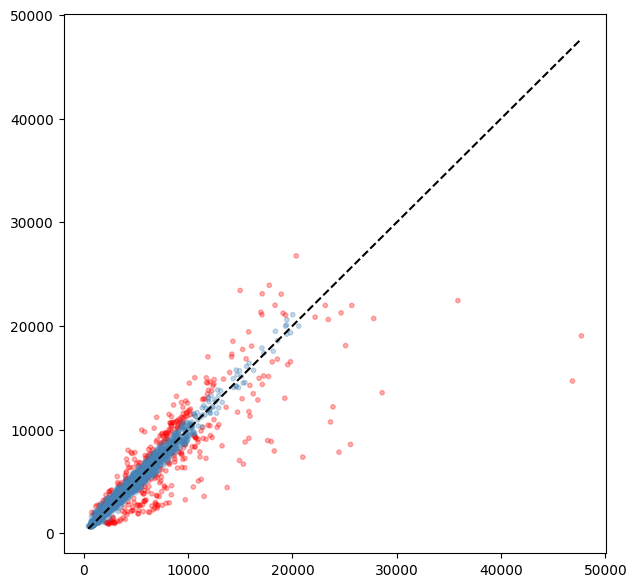

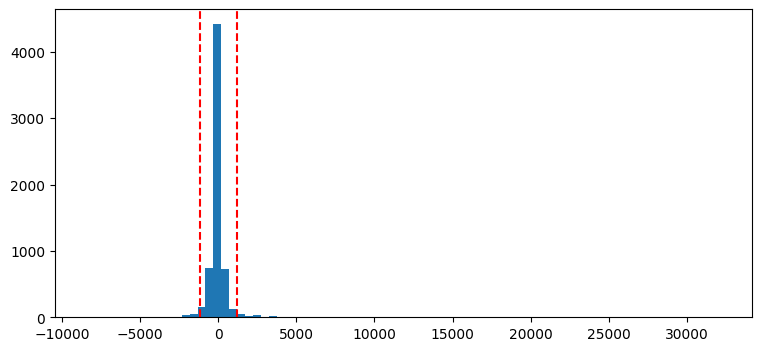

In [11]:
fig, ax = plt.subplots(figsize=(7, 7)); ax.scatter(y, oof_pred, s=10, alpha=0.3, c=df["reg_flag"].map({True: "red", False: "steelblue"})); lims = [y.min(), y.max()]; ax.plot(lims, lims, "k--"); plt.show(); fig, ax = plt.subplots(figsize=(9, 4)); ax.hist(df["residual"], bins=80); ax.axvline(threshold, color="red", ls="--"); ax.axvline(-threshold, color="red", ls="--"); plt.show()

In [12]:
imp = permutation_importance(model, X, y, n_repeats=5, random_state=42, scoring="neg_mean_absolute_error")
order = np.argsort(imp.importances_mean)[::-1]

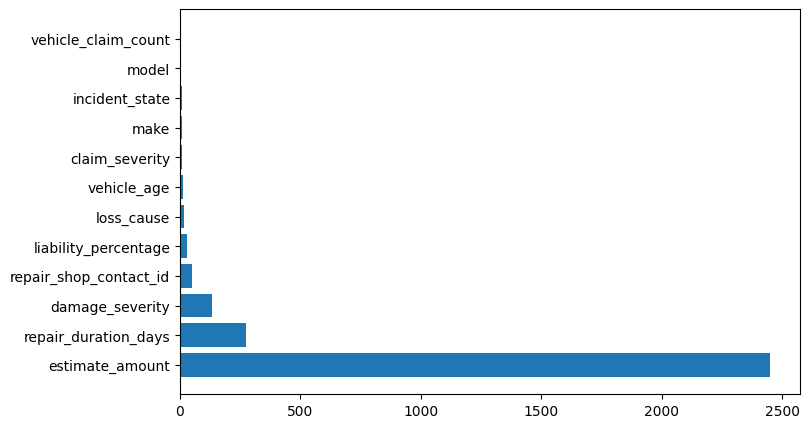

In [13]:
fig, ax = plt.subplots(figsize=(8, 5)); ax.barh(np.array(X.columns)[order], imp.importances_mean[order]); plt.show()

In [14]:
ct = pd.crosstab(df["reg_flag"], df["duplicate_flag"], normalize="index")
print(ct.round(3))
print(df.loc[df["reg_flag"], "duplicate_flag"].mean(), df["duplicate_flag"].mean())

duplicate_flag  False  True 
reg_flag                    
False           0.917  0.083
True            0.972  0.028
0.02786377708978328 0.07992565055762081


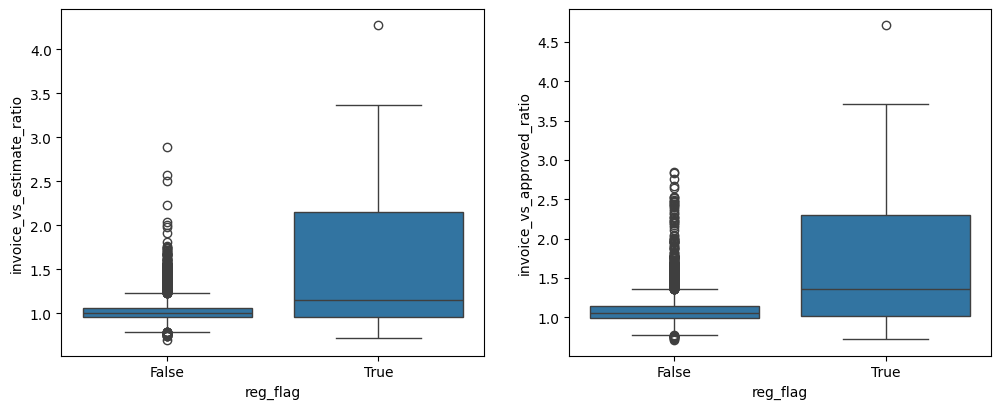

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, col in zip(axes, ["invoice_vs_estimate_ratio", "invoice_vs_approved_ratio"]):
    sns.boxplot(data=df, x="reg_flag", y=col, ax=ax)
plt.show()

In [16]:
def score_new_point(record, actual_invoice):
    row = pd.DataFrame([record])[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
    pred = model.predict(row)[0]
    resid = actual_invoice - pred
    return {"predicted": pred, "actual": actual_invoice, "residual": resid, "threshold": threshold, "reg_flag": abs(resid) > threshold}

In [17]:
typical_point = {"estimate_amount": 2265.50, "vehicle_age": 9, "liability_percentage": 85.0, "repair_duration_days": 6, "vehicle_claim_count": 1,
    "make": "Toyota", "model": "Camry", "damage_severity": "Moderate", "claim_severity": "Medium", "incident_state": "CA", "loss_cause": "Rear-end Collision", "repair_shop_contact_id": 217}

suspicious_point = {"estimate_amount": 2400.00, "vehicle_age": 2, "liability_percentage": 22.0, "repair_duration_days": 6, "vehicle_claim_count": 1,
    "make": "Tesla", "model": "Model 3", "damage_severity": "Minor", "claim_severity": "Low", "incident_state": "CA", "loss_cause": "Parking Lot Incident", "repair_shop_contact_id": 132}

In [18]:
print("typical", score_new_point(typical_point, 2320.00))
print("suspicious", score_new_point(suspicious_point, 18250.00))

typical {'predicted': 2320.006173234388, 'actual': 2320.0, 'residual': -0.006173234387915727, 'threshold': 1177.4583978084804, 'reg_flag': False}
suspicious {'predicted': 2565.2619005419456, 'actual': 18250.0, 'residual': 15684.738099458054, 'threshold': 1177.4583978084804, 'reg_flag': True}
